# Análisis Exploratorio de Datos (EDA)

## Carga de los datos

El **Análisis Exploratorio de Datos (EDA)** se realiza sobre el dataset completo *antes* de dividirlo en conjuntos de entrenamiento y prueba. Esto nos permite entender la estructura, distribuciones y relaciones de los datos, lo que orienta las decisiones sobre preprocesamiento e ingeniería de características.

> ⚠️ **Advertencia sobre fuga de datos**: Aunque el EDA se realiza sobre el dataset completo, es fundamental que cualquier *decisión* derivada de este análisis (como elegir estrategias de preprocesamiento o crear nuevas características) se *ajuste* solo sobre los datos de entrenamiento, una vez hecha la división. El objetivo del EDA es entender los datos, no optimizar para valores concretos que podrían filtrar información del futuro conjunto de prueba. Por ejemplo, aquí podemos observar que `median_income` está muy correlacionada con el objetivo, pero cuando más adelante apliquemos muestreo estratificado o ajustemos escaladores, debemos usar únicamente el conjunto de entrenamiento.

In [ ]:
import pandas as pdimport numpy as nphousing = pd.read_csv("./data/housing.csv") # Load the dataset

## Visualización geográfica de los datos

Creamos un gráfico de dispersión de todos los distritos para visualizar los datos geográficos.

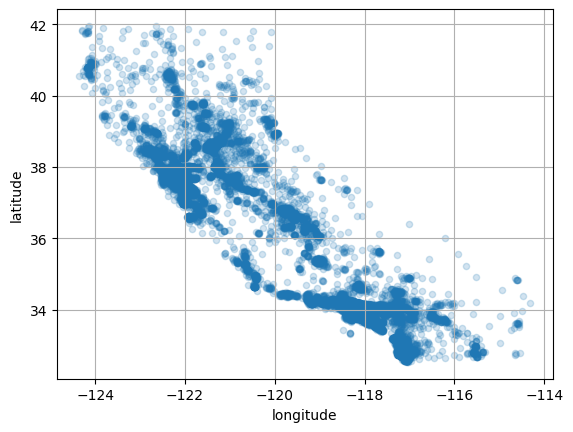

In [ ]:
import matplotlib.pyplot as plthousing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2);

Visualización de cada registro en su posición geográfica (latitud y longitud), con una escala de color que representa el precio medio de la vivienda y el tamaño del círculo proporcional a la población.

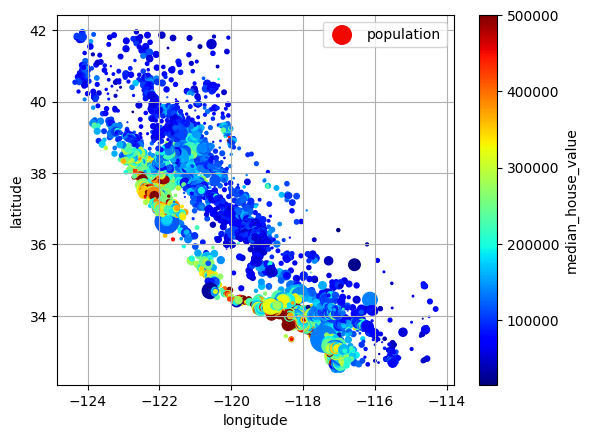

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,             s=housing["population"] / 100, # circle radius represents distrito population             label="population", # label for the legend             c="median_house_value", # point color represents mediana house valor             cmap="jet", # use the "jet" color palette             colorbar=True,             legend=True);

Colocamos lo mismo sobre un mapa.

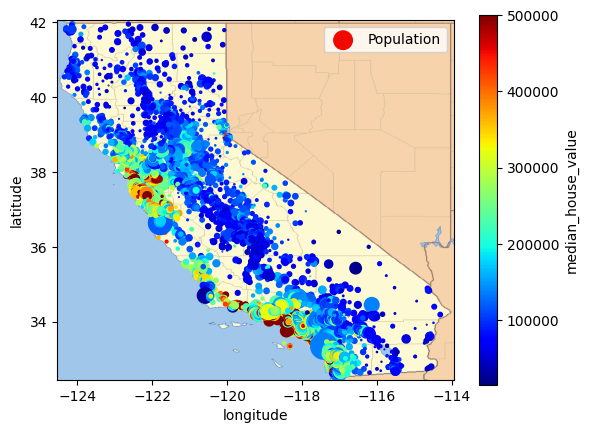

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude",             s=housing["population"] / 100, # circle size proportional to population             label="Population",              c="median_house_value", cmap="jet", colorbar=True,             legend=True)california_img = plt.imread("./img/california.png")axis = -124.55, -113.95, 32.45, 42.05plt.axis(axis)plt.imshow(california_img, extent=axis)plt.show()

Visualización geográfica de los valores de `ocean_proximity` con colores (será útil cuando procesemos esta variable categórica).

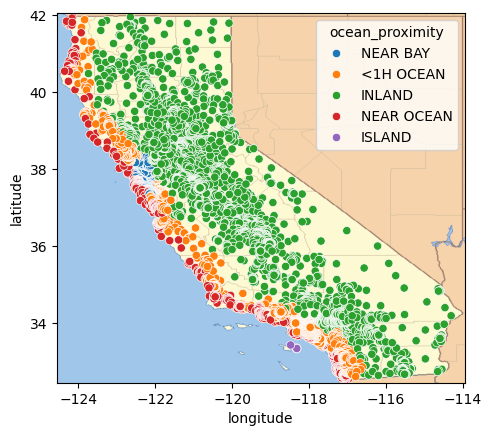

In [ ]:
import seaborn as snsimport PILimport matplotlib.pyplot as pltsns.scatterplot(x="longitude", y="latitude", hue="ocean_proximity", data=housing)axis = -124.55, -113.95, 32.45, 42.05 # longitude and latitude limits of the imageplt.imshow(PIL.Image.open("./img/california.png", mode='r'), extent=axis)plt.show()

## Búsqueda de correlaciones

El método `corr()` de pandas calcula el **coeficiente de correlación de Pearson (PCC)** entre cada par de atributos. Este coeficiente va de -1 a 1 e indica el grado de correlación lineal entre dos variables. Cuando se acerca a 1, hay una correlación positiva fuerte (las variables tienden a crecer juntas). Cuando se acerca a -1, hay una correlación negativa fuerte (una disminuye cuando la otra aumenta). Los coeficientes cercanos a 0 indican que no hay correlación lineal.

Usamos el argumento `numeric_only=True` para calcular la correlación solo entre variables numéricas, ignorando la variable categórica `ocean_proximity`.

In [ ]:
corr_matrix = housing.corr(numeric_only=True) 

Con esta matriz de correlación, veamos de forma ordenada qué variables correlacionan más con la **variable objetivo** `median_house_value`. El método `sort_values()` de pandas nos permite ordenar los valores de una serie; además, podemos usar el parámetro `key` para pasar una función que se aplicará a cada valor antes de ordenar. En este caso queremos ordenar por valor absoluto, ya que una correlación negativa fuerte es igual de interesante que una positiva.

In [ ]:
corr_matrix["median_house_value"].sort_values(ascending=False, key=np.abs) # ordenar valores by correlation with respect to absolute valor

median_house_value    1.000000
median_income         0.688075
latitude             -0.144160
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
longitude            -0.045967
population           -0.024650
Name: median_house_value, dtype: float64

Observamos que la variable que más correlaciona con `median_house_value` es `median_income`, con un coeficiente de 0,69. Es por tanto la ***feature*** que más determina los precios de la vivienda.

También podemos ver las correlaciones con un gráfico de dispersión de las variables más correlacionadas con `median_house_value`, usando la función `scatter_matrix` de pandas. En la diagonal vemos que coloca sus histogramas (como al principio) por defecto, ya que comparar una variable consigo misma daría únicamente una línea recta sin información útil.

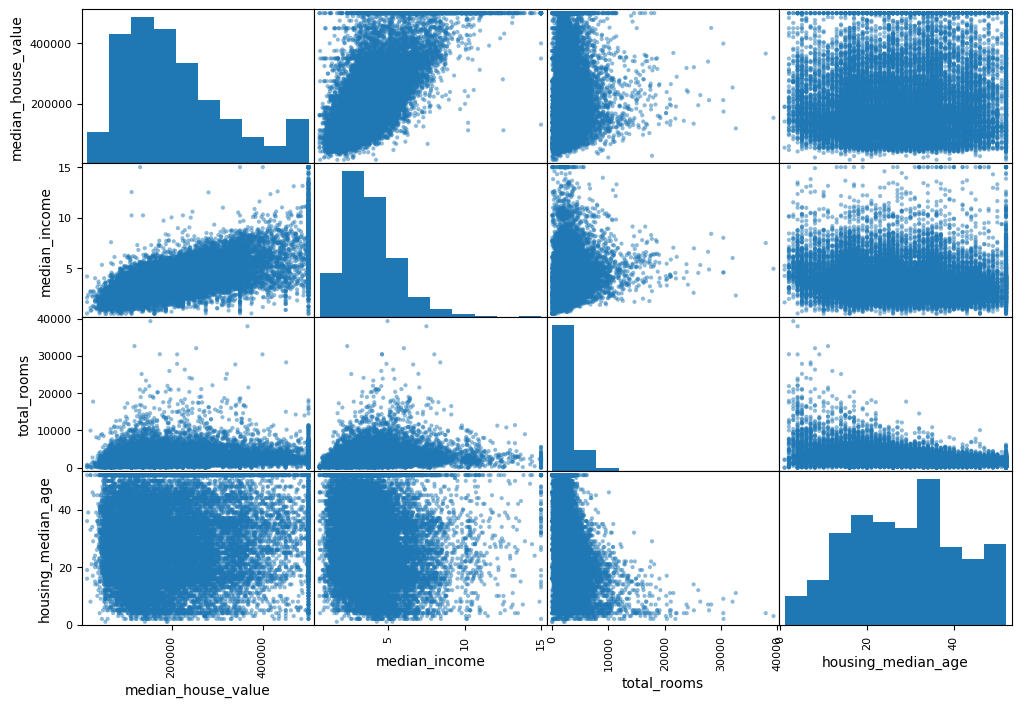

In [ ]:
from pandas.plotting import scatter_matrixattributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]scatter_matrix(housing[attributes], figsize=(12, 8));

De nuevo vemos cómo la correlación más clara es con `median_income`: cuanto más aumenta, más sube el precio medio de la vivienda. También podemos apreciar que el límite de 500.000 USD mencionado antes es claramente visible en la gráfica, como una línea horizontal en la parte superior del eje y.

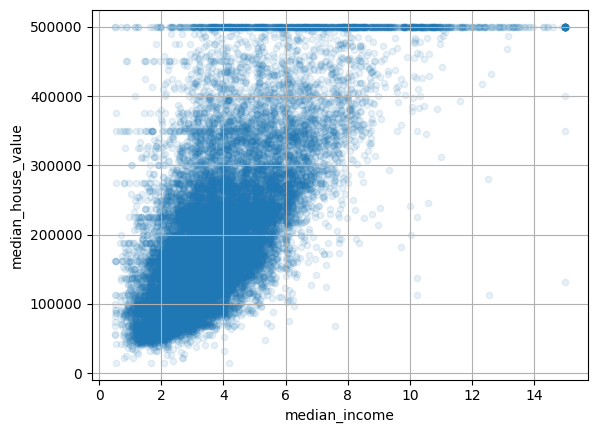

In [ ]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, grid=True);

## Valores atípicos y valores truncados

Como observamos en el [notebook de encuadramiento](e2e010_framing.ipynb), algunas variables de este dataset han sido **truncadas (capped)**: los valores que superan cierto umbral se han reemplazado por ese valor límite. Esto es evidente en los histogramas de `housing_median_age` (truncada en 52) y `median_house_value` (truncada en 500.001 USD), donde se ve una barra muy alta en el valor máximo.

Esta es una de varias técnicas para tratar los **valores atípicos** — puntos de datos que se alejan mucho del grueso de la distribución. Los enfoques más habituales son:

- **Truncamiento (capping o clipping)**: Reemplazar los valores que superan un umbral fijo por ese umbral. Es lo que se aplicó a este dataset. Por ejemplo, todos los precios de vivienda superiores a 500.000 USD se fijaron en 500.001 USD. Preserva el número de observaciones pero pierde información sobre la magnitud de los valores extremos.
- **Winsorización**: Similar al truncamiento, pero los umbrales se definen como percentiles (por ejemplo, los percentiles 1 y 99) en lugar de valores fijos. Es más riguroso estadísticamente cuando el umbral apropiado no se conoce de antemano.
- **Eliminación (truncation o trimming)**: Eliminar directamente las observaciones que superan el umbral. A diferencia del truncamiento, reduce el tamaño de la muestra.

Estas técnicas importan porque los valores atípicos pueden afectar de forma desproporcionada a:

- **Imputación por media**: La media es sensible a valores extremos, por lo que la imputación por mediana es preferible cuando hay valores atípicos (véase el [notebook de Valores Faltantes](e2e041_missing.ipynb)).
- **Escalado Min-Max**: Un único valor extremo puede comprimir todo el rango de valores "normales" en un intervalo muy pequeño (véase el [notebook de Escalado](e2e043_scaling.ipynb)).
- **Entrenamiento del modelo**: Muchos algoritmos (especialmente los basados en distancias o gradientes) pueden verse distorsionados por valores extremos.

En este dataset, el truncamiento se aplicó *antes* de que recibiéramos los datos. Cuando se trabaja con datos sin procesar, la decisión de si y cómo tratar los valores atípicos debe tomarse con cuidado, considerando si los valores extremos representan errores, observaciones raras pero válidas, o poblaciones genuinamente distintas.

Los hallazgos del EDA —especialmente las correlaciones entre variables— conducen de forma natural a la **Ingeniería de Características**: crear nuevas variables que puedan ser más predictivas que las características originales. Esto se trata en el [notebook de Ingeniería de Características](e2e030_feature_engineering.ipynb).